# Baseline: TF-IDF + Logistic Regression

Chunk-level clause detection with one TF-IDF + logistic regression model per category. This is the baseline the transformer model has to beat.
All the logic is in `scripts/baseline_tfidf.py`. Running `python scripts/baseline_tfidf.py` regenerates `results/baseline_tfidf_lr/shortlist/` without Jupyter.

* **Data:** `data/processed/` contracts and annotations, split by `splits.csv` (323 train / 84 val / 102 test contracts).
* **Chunks:** 512 `bert-base-uncased` tokens with a 64-token overlap, as in `chunking.ipynb`. A chunk is positive for a category if it overlaps an annotated span.
* **Categories:** the 14 shortlisted in `data/eda/category_profile.csv` (all 41 in section 6).
* **Model:** word 1–2-gram TF-IDF fitted on train chunks, and a class-weighted logistic regression per category.
* **Tuning:** `C` and a per-category threshold are chosen on validation. The test set is scored once.
* **Metrics:** precision, recall, F1 and average precision per category, at chunk level and at contract level (a contract is flagged if any of its chunks is).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("../scripts").resolve()))
from baseline_tfidf import run_baseline, save_results, RESULTS_DIR

pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 120)

## 1. Train, tune on validation, score test

In [2]:
result = run_baseline()
save_results(result)
print(f"chosen C = {result.C}")

contracts: {'train': 323, 'test': 102, 'val': 84}  categories: 14


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


chunks: {'train': 7944, 'val': 2317, 'test': 2217}  (8s)
tf-idf vocabulary: 126,086 n-grams
  C=0.25  val macro AP=0.548
  C=1.0   val macro AP=0.581
  C=4.0   val macro AP=0.605
  C=16.0  val macro AP=0.616
  C=64.0  val macro AP=0.620
done in 29s
chosen C = 64.0


## 2. Headline numbers (test set)

In [3]:
result.summary

,chunk_level,contract_level
macro_precision,0.644,0.823
macro_recall,0.576,0.798
macro_f1,0.587,0.797
macro_avg_precision,0.639,0.879
micro_precision,0.646,0.826
micro_recall,0.588,0.807
micro_f1,0.615,0.817


## 3. Per category

In [4]:
cols = ["positives", "positive_rate", "precision", "recall", "f1", "avg_precision"]
per_cat = pd.concat({"chunk": result.chunk_metrics[cols], "contract": result.contract_metrics[cols]}, axis=1)
per_cat.sort_values(("chunk", "f1"), ascending=False)

chunk                                        \
                            positives positive_rate precision recall     f1   
category                                                                      
License Grant                     125         0.056     0.774  0.768  0.771   
Audit Rights                       74         0.033     0.724  0.743  0.733   
Anti-Assignment                   126         0.057     0.937  0.587  0.722   
Insurance                          61         0.028     0.667  0.787  0.722   
Cap on Liability                   99         0.045     0.921  0.586  0.716   
Non-Compete                        59         0.027     0.611  0.559  0.584   
Revenue/Profit Sharing             74         0.033     0.706  0.486  0.576   
Minimum Commitment                 82         0.037     0.704  0.463  0.559   
Exclusivity                        71         0.032     0.483  0.606  0.538   
Termination for Convenience        37         0.017     0.426  0.703  0.531   
Post-Termination Services          72         0.032     0.438  0.542  0.484   
Non-Transferable License           40         0.018     0.426  0.500  0.460   
IP Ownership Assignment            55         0.025     0.429  0.491  0.458   
Change of Control                  58         0.026     0.778  0.241  0.368   

                                           contract                          \
                            avg_precision positives positive_rate precision   
category                                                                      
License Grant                       0.840        50         0.490     1.000   
Audit Rights                        0.766        38         0.373     0.921   
Anti-Assignment                     0.809        72         0.706     0.983   
Insurance                           0.769        32         0.314     0.966   
Cap on Liability                    0.796        44         0.431     0.950   
Non-Compete                         0.653        23         0.225     0.818   
Revenue/Profit Sharing              0.646        35         0.343     0.913   
Minimum Commitment                  0.572        32         0.314     0.929   
Exclusivity                         0.555        33         0.324     0.771   
Termination for Convenience         0.556        29         0.284     0.533   
Post-Termination Services           0.473        29         0.284     0.625   
Non-Transferable License            0.475        22         0.216     0.607   
IP Ownership Assignment             0.475        23         0.225     0.645   
Change of Control                   0.562        26         0.255     0.857   

                                                         
                            recall     f1 avg_precision  
category                                                 
License Grant                0.880  0.936         0.983  
Audit Rights                 0.921  0.921         0.955  
Anti-Assignment              0.819  0.894         0.984  
Insurance                    0.875  0.918         0.973  
Cap on Liability             0.864  0.905         0.972  
Non-Compete                  0.783  0.800         0.833  
Revenue/Profit Sharing       0.600  0.724         0.911  
Minimum Commitment           0.812  0.867         0.935  
Exclusivity                  0.818  0.794         0.850  
Termination for Convenience  0.828  0.649         0.727  
Post-Termination Services    0.862  0.725         0.799  
Non-Transferable License     0.773  0.680         0.752  
IP Ownership Assignment      0.870  0.741         0.832  
Change of Control            0.462  0.600         0.805

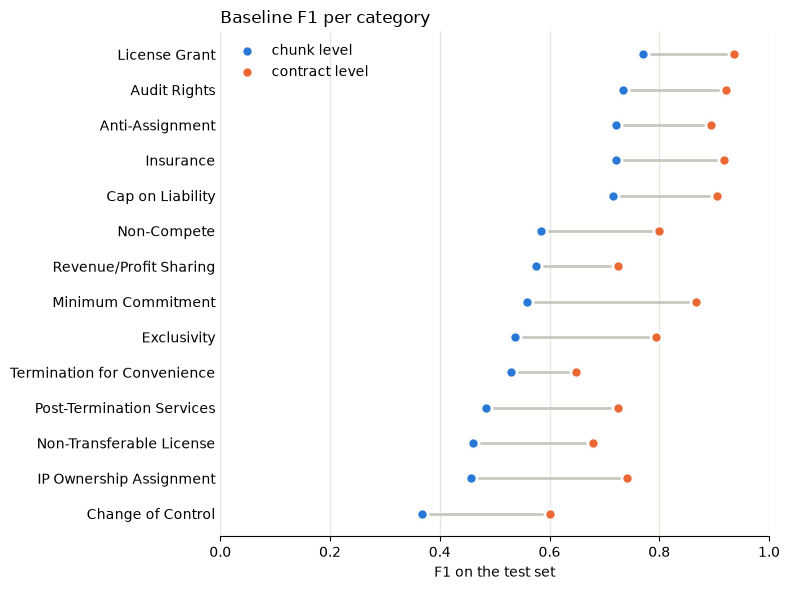

In [5]:
# Chunk-level vs contract-level F1 per category, sorted by chunk F1
order = result.chunk_metrics.sort_values(by="f1").index
chunk_f1 = result.chunk_metrics.loc[order, "f1"]
contract_f1 = result.contract_metrics.loc[order, "f1"]
y = range(len(order))

fig, ax = plt.subplots(figsize=(8, 6))
ax.hlines(y, chunk_f1, contract_f1, color="#c8c7c0", linewidth=2, zorder=1)
ax.scatter(chunk_f1, y, s=64, color="#2a78d6", label="chunk level", zorder=2,
           edgecolors="#fcfcfb", linewidths=2)
ax.scatter(contract_f1, y, s=64, color="#eb6834", label="contract level", zorder=2,
           edgecolors="#fcfcfb", linewidths=2)
ax.set_yticks(list(y), order)
ax.set_xlim(0, 1)
ax.set_xlabel("F1 on the test set")
ax.set_title("Baseline F1 per category", loc="left")
ax.grid(axis="x", color="#e8e7e1", linewidth=1)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## 4. Top n-grams per category

In [6]:
result.features

,top_ngrams
category,
Anti-Assignment,"assignment, assign, consent, written consent, consent of, without the, may assign, the prior, prior written, be assi..."
Cap on Liability,"damages, consequential, liability, be liable, limitation of, indirect, liable, warranty, special, punitive, of liabi..."
License Grant,"grants, license, grants to, hereby grants, license to, non-exclusive, to use, use, grant, a non-exclusive, hereby, r..."
Audit Rights,"audit, records, inspection, inspect, business hours, books, audits, hours, normal business, to inspect, normal, such..."
Post-Termination Services,"termination, termination of, expiration, of termination, or expiration, termination or, upon termination, inventory,..."
Termination for Convenience,"termination, terminate, any time, at any, may terminate, terminate this, written notice, agreement at, terminated, t..."
Exclusivity,"exclusive, exclusivity, the exclusive, an exclusive, exclusive right, territory, sell, grant, grants, license, exclu..."
Insurance,"insurance, coverage, liability insurance, such insurance, liability, of insurance, insured, maintain, additional ins..."
Minimum Commitment,"minimum, the minimum, minimum of, a minimum, least, at least, less than, less, year, annual, 000, volume"


## 5. Error examples

In [7]:
import textwrap
from load_dataset import load_annotations

annotations = load_annotations().set_index(["contract_id", "category"])["annotations"]
pred = result.test_predictions
test_chunks = result.chunks.loc[result.chunks["split"] == "test"].set_index(["contract_id", "chunk_index"])
features = result.features["top_ngrams"]

def show(category: str, kind: str, n: int = 2, width: int = 110) -> None:
    prob_col = f"prob__{category}"
    p, lab = pred[prob_col], pred[f"label__{category}"]
    thr = result.thresholds[category]
    if kind == "missed":
        rows = pred.loc[(lab == 1) & (p < thr)].sort_values(by=prob_col)
    else:
        rows = pred.loc[(lab == 0) & (p >= thr)].sort_values(by=prob_col, ascending=False)
    print(f" {category}: {kind} ({len(rows)} chunks, threshold {thr:.2f}) ")
    for _, r in rows.head(n).iterrows():
        cid, chunk_index = str(r["contract_id"]), int(r["chunk_index"])
        if kind == "missed":  # show the annotated clause the chunk overlaps
            spans = [a for a in annotations.loc[(cid, category)]
                     if a["start"] < r["end"] and a["end"] > r["start"]]
            snippet = str(spans[0]["text"])
        else:                 # show the text around the first strong n-gram
            text = str(test_chunks.loc[(cid, chunk_index), "text"])
            low = text.lower()
            hits = [low.find(g.strip()) for g in str(features[category]).split(",")[:5]]
            at = min([h for h in hits if h >= 0], default=0)
            snippet = text[max(at - 150, 0): at + 250]
        print(f"\n[{cid[:60]} | chunk {chunk_index} | p={r[prob_col]:.2f}]")
        print(textwrap.fill(" ".join(snippet.split())[:450], width))
    print()

show("Change of Control", "missed")
show("Post-Termination Services", "false alarm")

 Change of Control: missed (44 chunks, threshold 0.52) 

[HALITRON,INC_03_01_2005-EX-10.15-SPONSORSHIP AND DEVELOPMENT | chunk 10 | p=0.00]
an affiliated, parent, subsidiary, related company (or in the case of the production of Advertising Materials
to an advertising agency representing TDA) so as to effectuate the intent of this Agreement and the subject
matter hereof, although TDA will continue to be liable for all financial obligations hereunder.

[PACIRA PHARMACEUTICALS, INC. - A_R STRATEGIC LICENSING, DIST | chunk 25 | p=0.00]
Offsets and/or repayment of the Advanced Royalty Payment shall commence on [**] and shall continue, unless
sooner paid, through [**] (the "Royalty Offset Period") and such offsets will be taken by EKR (and such
repayment will be made by PPI) as follows:

 Post-Termination Services: false alarm (50 chunks, threshold 0.24) 

[DovaPharmaceuticalsInc_20181108_10-Q_EX-10.2_11414857_EX-10. | chunk 66 | p=0.99]
eriod. Sections 6.3, 6.4 and 6.5 shall apply, mutatis 

## 6. All 41 categories

Reads `results/baseline_tfidf_lr/all_categories/`, written by `python scripts/baseline_tfidf.py --categories all`.
*Price Restrictions* has no clauses in the test set, so its recall and average precision are undefined and it is left out of the averages.

In [8]:
all_dir = RESULTS_DIR / "all_categories"
all_summary = pd.read_csv(all_dir / "metrics_summary.csv", index_col=0)
all_chunk = pd.read_csv(all_dir / "metrics_chunk_level.csv", index_col=0)
display(all_summary)
all_chunk.sort_values(by="f1", ascending=False)[["positives", "precision", "recall", "f1", "avg_precision"]]

,chunk_level,contract_level
macro_precision,0.580,0.718
macro_recall,0.560,0.719
macro_f1,0.550,0.696
macro_avg_precision,0.593,0.786
micro_precision,0.637,0.814
micro_recall,0.626,0.804
micro_f1,0.632,0.809


,positives,precision,recall,f1,avg_precision
category,,,,,
Governing Law,116,0.862,0.862,0.862,0.876
Parties,131,0.889,0.794,0.839,0.903
Expiration Date,103,0.862,0.786,0.822,0.858
Source Code Escrow,3,1.000,0.667,0.800,0.867
License Grant,125,0.774,0.768,0.771,0.840
Agreement Date,96,0.809,0.708,0.756,0.800
Audit Rights,74,0.724,0.743,0.733,0.766
No-Solicit of Employees,16,0.706,0.750,0.727,0.804
Renewal Term,39,0.653,0.821,0.727,0.764


## Findings

**Headline (test set, 14 categories):** chunk macro F1 **0.59** (micro 0.62), contract macro F1 **0.80** (micro 0.82).

1. **Distinctive vocabulary is easy.** *License Grant*, *Audit Rights*, *Insurance*, *Anti-Assignment* and *Cap on Liability* reach chunk F1 of 0.72–0.77, keyed on n-grams such as "hereby grants", "audit" and "insurance".
2. **Overlapping categories are hard.** *IP Ownership Assignment* (0.46), *Non-Transferable License* (0.46) and *Post-Termination Services* (0.48) are confused with neighbouring clauses: 25 of 27 *Non-Transferable License* false alarms are *License Grant* clauses. *Change of Control* (0.37) is weak for a different reason (finding 3).
3. **Change of Control misses most clauses** (precision 0.78, recall 0.24). Lowering its threshold would trade precision for recall.
4. **Contract level is much easier than chunk level**, because one confident chunk is enough. Contract recall is higher in every category.
5. **Rare categories are unreliable.** Across all 41 categories chunk macro F1 drops to 0.55. Categories with 3–12 positive test chunks range from 0.00 (*Most Favored Nation*) to 0.80 (*Source Code Escrow*), too few to measure either way.
6. **Some errors come from the annotations.** CUAD sometimes labels a list's lead-in sentence as its own span, so a chunk holding only that sentence is positive with no clause wording in it. 19 of 50 *Post-Termination Services* false alarms are survival clauses, which are borderline rather than wrong.
7. **Tuning.** Validation AP flattens out by C=64 (+0.004 over C=16). Class weighting barely changes validation AP (0.620 vs 0.617 unweighted). It matters at the default 0.5 threshold (validation F1 0.58 vs 0.45), and per-category thresholds take care of that.